# 딥러닝 라이브러리 2가지
## 텐서플로우(google) - 산업용
* 이미지 관련 라이브러리
* keras를 이용해 코딩이 쉬움
* 순차적, 함수적, 클래스

## 파이토치(meta) - 연구용
* 자연어 관련 라이브러리
* 허깅페이스, 랭체인
* 클래스 기반

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/Taitanic_train.csv")
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [3]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
data = data[['Survived', 'Pclass','Sex', 'Age', 'SibSp', 'Parch', 'Embarked']]

In [5]:
data.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C


In [6]:
data['family'] = data["SibSp"] + data['Parch']

In [7]:
data['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [8]:
data.loc[:, 'Age'] = data['Age'].fillna(data['Age'].mean())
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,family
0,0,3,male,22.000000,1,0,S,1
1,1,1,female,38.000000,1,0,C,1
2,1,3,female,26.000000,0,0,S,0
3,1,1,female,35.000000,1,0,S,1
4,0,3,male,35.000000,0,0,S,0
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,S,0
887,1,1,female,19.000000,0,0,S,0
888,0,3,female,29.699118,1,2,S,3
889,1,1,male,26.000000,0,0,C,0


In [9]:
data['Embarked'].mode()[0]

'S'

In [10]:
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Embarked  891 non-null    object 
 7   family    891 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 55.8+ KB


In [12]:
data = data.drop(['SibSp', 'Parch'], axis = 1)
data

,Survived,Pclass,Sex,Age,Embarked,family
0,0,3,male,22.000000,S,1
1,1,1,female,38.000000,C,1
2,1,3,female,26.000000,S,0
3,1,1,female,35.000000,S,1
4,0,3,male,35.000000,S,0
...,...,...,...,...,...,...
886,0,2,male,27.000000,S,0
887,1,1,female,19.000000,S,0
888,0,3,female,29.699118,S,3
889,1,1,male,26.000000,C,0


In [13]:
data = pd.get_dummies(data, drop_first=True)
data

,Survived,Pclass,Age,family,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.000000,1,True,False,True
1,1,1,38.000000,1,False,False,False
2,1,3,26.000000,0,False,False,True
3,1,1,35.000000,1,False,False,True
4,0,3,35.000000,0,True,False,True
...,...,...,...,...,...,...,...
886,0,2,27.000000,0,True,False,True
887,1,1,19.000000,0,False,False,True
888,0,3,29.699118,3,False,False,True
889,1,1,26.000000,0,True,False,False


In [14]:
X = data.drop('Survived', axis = 1)
y = data['Survived']

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify=y, random_state=42)

# 딥러닝시에도 데이터의 스케일을 맞춰주는 것이 좋다.
* StandardScaler, MinMaxScaler를 주로 사용, 이상값이 많을때는 RobustScaler를 사용하고, 이상값이 많을경우 RobustScaler를 사용
* 이진분류(0,1) : MinMaxScaler
* 연속값예측 : StandardScaler

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
mms = MinMaxScaler()
mms_X_train = mms.fit_transform(X_train)
mms_X_test = mms.transform(X_test)
mms_X_train = pd.DataFrame(mms_X_train, columns=X_train.columns, index = X_train.index)
mms_X_test = pd.DataFrame(mms_X_test, columns=X_test.columns, index = X_test.index)
display(mms_X_train)
display(mms_X_test)

,Pclass,Age,family,Sex_male,Embarked_Q,Embarked_S
748,0.0,0.233476,0.1,1.0,0.0,1.0
45,1.0,0.367921,0.0,1.0,0.0,1.0
28,1.0,0.367921,0.0,0.0,1.0,0.0
633,0.0,0.367921,0.0,1.0,0.0,1.0
403,1.0,0.346569,0.1,1.0,0.0,1.0
...,...,...,...,...,...,...
476,0.5,0.421965,0.1,1.0,0.0,1.0
190,0.5,0.396833,0.0,0.0,0.0,1.0
736,1.0,0.597889,0.4,0.0,0.0,1.0
462,0.0,0.585323,0.0,1.0,0.0,1.0


,Pclass,Age,family,Sex_male,Embarked_Q,Embarked_S
625,0.0,0.761247,0.0,1.0,0.0,1.0
566,1.0,0.233476,0.0,1.0,0.0,1.0
459,1.0,0.367921,0.0,1.0,1.0,0.0
804,1.0,0.334004,0.0,1.0,0.0,1.0
338,1.0,0.560191,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...
184,1.0,0.044986,0.2,0.0,0.0,1.0
607,0.0,0.334004,0.0,1.0,0.0,1.0
624,1.0,0.258608,0.0,1.0,0.0,1.0
103,1.0,0.409399,0.0,1.0,0.0,1.0


# Tensorflow Sequential API를 사용한 순차적 모델 생성 및 분석
* Sequential : 인공신경망을 순차적으로 작성할 때 사용
* Dense : 층, 레이어
* 1. 신경망 모델 정의
* 2. 신경망 모델 훈련
* 3. 훈련된 모델로 테스트
* 4. 검증

In [19]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2025-05-14 15:39:02.626593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747204742.637398   27934 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747204742.640476   27934 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747204742.649217   27934 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747204742.649233   27934 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747204742.649234   27934 computation_placer.cc:177] computation placer alr

* 입력층은 반드시 독립변수의 수(input_dim)를 정확히 지정해야 한다
* 신경망 모델의 은닉층은 2~3개 정도로 한다
* Dense의 노드 수는 2의 배수를 지정 2 4 8 16...
* Dense의 노드는 큰 수에서 작은 수로 줄여나가야 한다
* 은닉층의 활성화 함수 : Reru
* 출력층은 이진분류일 경우 sigmoid, 다중분류, softmax
* 회귀분석일 경우(종속변수가 연속형(수치형)인 경우) 활성화 함수 없이 노드를 1로 지정

In [20]:
# 신경망 모델 정의 keras 3.0, tensorflow 2.19 기준
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1],))) #입력층
# model.add(Dense(64, input_dim = mms_X_train.shpae[1], activation='relu')) # 입력층
model.add(Dense(64, activation='relu')) # 은닉층
model.add(Dense(32, activation='relu')) # 은닉층
model.add(Dense(16, activation='relu')) # 은닉층
model.add(Dense(1, activation='sigmoid')) # 출력층, 이진분류이므로 sigmoid

I0000 00:00:1747204744.577190   27934 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9711 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:08:00.0, compute capability: 8.6


# 모델의 파라미터 세팅 model.compile()
* loss : 오차 계산 지표
    * 이진분류 : binary_crossentropy
    * 다중분류 : categorical_crossentropy
    * 데이터에 0이 많은 희소행렬인 경우 : sparse_categorical_crossentropy
    * 연속형데이터(회귀분석) : mse
* optimizer : learning_rate
    * adam을 가장 많이 사용
* metrics : 평가지표 accuracy

In [21]:
# 모델의 파라미터 세팅
model.compile(loss="binary_crossentropy", optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
len(mms_X_train)

623

# 모델 훈련 model.fit(X_train, y_trian)
* epochs : 전체 데이터를 한 번 훈련하는 주기
* batch_size : 전체 데이터를 쪼개서 훈련하는 것. 데이터의 묶음, 메모리에 맞춰서 크기를 조절해야 한다(2의 배수로 값을 주어야 함) 보통 32, 64로 쪼개서 넣는 것을 추천
* validation_data : 검증 데이터로 모델 검증 실시

In [23]:
history = model.fit(mms_X_train, y_train, epochs=100, batch_size = 16, validation_data=(mms_X_test, y_test))
# gpu 전용메모리 사용하고잇는지 확인하는법 : ctrl+shift+esc - 성능탭에서 gpu 전용메모리 칸에서 색칠되는지 확인인

Epoch 1/100


I0000 00:00:1747204746.070605   27998 service.cc:152] XLA service 0x7fb42000be60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747204746.070629   27998 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-05-14 15:39:06.087766: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747204746.219992   27998 cuda_dnn.cc:529] Loaded cuDNN version 90300


30/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6687 - loss: 0.6168

I0000 00:00:1747204747.026947   27998 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.6740 - loss: 0.6113 - val_accuracy: 0.7575 - val_loss: 0.5504
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7870 - loss: 0.5402 - val_accuracy: 0.7948 - val_loss: 0.5014
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7431 - loss: 0.5438 - val_accuracy: 0.7948 - val_loss: 0.4785
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7743 - loss: 0.5015 - val_accuracy: 0.7985 - val_loss: 0.4671
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8282 - loss: 0.4326 - val_accuracy: 0.8060 - val_loss: 0.4581
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8006 - loss: 0.4621 - val_accuracy: 0.8097 - val_loss: 0.4513
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7939 - loss: 0.4721 - val_accuracy: 0.8060 - val_loss: 0.4481
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8097 - loss: 0.4420 - val_accuracy: 0.8060 - val_loss: 0.

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8395 - loss: 0.4020 - val_accuracy: 0.7948 - val_loss: 0.4290
Epoch 52/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8208 - loss: 0.4425 - val_accuracy: 0.8134 - val_loss: 0.4209
Epoch 53/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8133 - loss: 0.4227 - val_accuracy: 0.7873 - val_loss: 0.4316
Epoch 54/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8116 - loss: 0.4322 - val_accuracy: 0.7910 - val_loss: 0.4289
Epoch 55/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8197 - loss: 0.4305 - val_accuracy: 0.8246 - val_loss: 0.4222
Epoch 56/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8463 - loss: 0.4009 - val_accuracy: 0.8209 - val_loss: 0.4200
Epoch 57/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8136 - loss: 0.4298 - val_accuracy: 0.8209 - val_loss: 0.4263
Epoch 58/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8462 - loss: 0.3774 - val_accuracy: 0.8022 - val_lo

# 딥러닝 모델 성능 평가
* 딥러닝에서 모델의 성능을 평가하는 지표는 loss를 확인해야 한다. loss가 작은 게 좋음
* 보통 loss가 낮으면 accuracy가 올라가지만, 비례하지 않을 때도 있다
* accuracy와 loss간의 차이가 있을 때 loss가 낮은 모델이 우수한 모델

In [24]:
score = model.evaluate(mms_X_test, y_test)
print('test loss', score[0])
print('test accuracy', score[1])

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8169 - loss: 0.4261  
test loss 0.4304771423339844
test accuracy 0.8097015023231506


In [25]:
history.history['loss']

[0.592653214931488,
 0.5240320563316345,
 0.49060532450675964,
 0.4723716378211975,
 0.4667604863643646,
 0.45632174611091614,
 0.4524787366390228,
 0.454628586769104,
 0.4403887987136841,
 0.44000306725502014,
 0.4373597502708435,
 0.4353717565536499,
 0.4360826313495636,
 0.4310658872127533,
 0.43125125765800476,
 0.4291594326496124,
 0.4282297194004059,
 0.42634060978889465,
 0.42599859833717346,
 0.4290810227394104,
 0.4242549240589142,
 0.42703795433044434,
 0.4204731583595276,
 0.42256784439086914,
 0.4222712814807892,
 0.4191782772541046,
 0.41628748178482056,
 0.4168035089969635,
 0.4170807898044586,
 0.4175712764263153,
 0.41618403792381287,
 0.415452241897583,
 0.4153348207473755,
 0.41791319847106934,
 0.4124309718608856,
 0.4258762300014496,
 0.4174218773841858,
 0.4160003960132599,
 0.4161885380744934,
 0.4145433306694031,
 0.41447755694389343,
 0.41364505887031555,
 0.4115120470523834,
 0.414415180683136,
 0.41180840134620667,
 0.41467902064323425,
 0.409158855676651,
 0.

In [26]:
for i in history.history :
    print(i)

accuracy
loss
val_accuracy
val_loss


# 훈련 결과 시각화하기
### history.history['loss']
### history.history['val_loss']

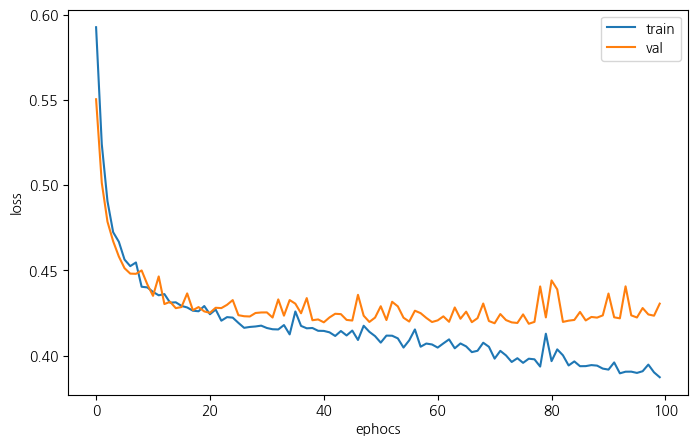

In [27]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('ephocs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()
# train(파란선)이 훈련데이터, val(주황선)이 테스트데이터
# 모델 자체가 랜덤성이 강하므로 같은 데이터를 다른 사람이 해도 다른 결과가 나온다.

# 모델의 예측 값 출력

In [28]:
pred = model.predict(mms_X_test)
pred

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([[0.39253944],
       [0.14996307],
       [0.13075244],
       [0.11875249],
       [0.07933079],
       [0.39806134],
       [0.12669738],
       [0.87438554],
       [0.11129544],
       [0.9472607 ],
       [0.82218015],
       [0.9939732 ],
       [0.39062247],
       [0.39260364],
       [0.750865  ],
       [0.89052194],
       [0.13075244],
       [0.41646516],
       [0.928752  ],
       [0.40761906],
       [0.06365743],
       [0.1195977 ],
       [0.53177   ],
       [0.11875249],
       [0.3065461 ],
       [0.17752226],
       [0.9760499 ],
       [0.30439898],
       [0.4461588 ],
       [0.21706536],
       [0.9174117 ],
       [0.95792294],
       [0.13075244],
       [0.8774112 ],
       [0.99168855],
       [0.53439236],
       [0.13075244],
       [0.08368994],
       [0.13075244],
       [0.4072718 ],
       [0.12669738],
       [0.9204029 ],
       [0.46435663],
       [0.99043536],
       [0.98845065],
       [0.17389797],
       [0.5386889 ],
       [0.341

In [29]:
pred_df = pd.DataFrame(pred)

In [31]:
pred_df

,0
0,0.392539
1,0.149963
2,0.130752
3,0.118752
4,0.079331
...,...
263,0.741862
264,0.409967
265,0.136162
266,0.104389


In [35]:
result = pd.DataFrame(dict(y_test=y_test, pred=pred))
result

ValueError: Per-column arrays must each be 1-dimensional

In [32]:
result['pred'] = result['pred'].apply(lambda x : 1 if x >= 0.5 else 0)
result

NameError: name 'result' is not defined

In [36]:
from sklearn.metrics import classification_report
print(classification_report(result['y_test'], result['pred']))

NameError: name 'result' is not defined

# Function  API를 이용한 함수형 모델
* Sequential API는 단순히 층을 여러개 쌓는 형태라 복잡한 모델 생성에 한계가 있음
* Functional API는 입력층과 출력층을 사용자가 직접 정의 가능
* 다중입력(Multi-input), 다중출력(Multi-output) 등 복잡한 모델을 정의할 수 있음
* Input(shape = (독립변수)) 로 입력층 정의
* 이전층을 다음 층의 입력으로 사용
* model()에 입력과 출력을 정의함

In [37]:
# tensorflow 2.19 버전 기준
from keras.layers import Input, Dense
from keras.models import Model

In [39]:
# 입력층
inputs = Input(shape=(mms_X_train.shape[1],))
# 은닉층
x = Dense(64 #(노드 수)
          , activation='relu')(inputs)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)

# 출력층
outputs = Dense(1, activation='sigmoid')(x)

# 모델 정의
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8648 - loss: 0.3473 - val_accuracy: 0.7985 - val_loss: 0.4366
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8393 - loss: 0.3864 - val_accuracy: 0.8209 - val_loss: 0.4345
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8353 - loss: 0.3881 - val_accuracy: 0.8134 - val_loss: 0.4352
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8503 - loss: 0.3699 - val_accuracy: 0.7873 - val_loss: 0.4396
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8492 - loss: 0.3719 - val_accuracy: 0.8097 - val_loss: 0.4348
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8448 - loss: 0.3999 - val_accuracy: 0.8172 - val_loss: 0.4359
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8369 - loss: 0.3931 - val_accuracy: 0.8134 - val_loss: 0.4363
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8510 - loss: 0.3450 - val_accuracy: 0.8097 - 

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8603 - loss: 0.3528 - val_accuracy: 0.8022 - val_loss: 0.4656
Epoch 52/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8447 - loss: 0.3729 - val_accuracy: 0.7985 - val_loss: 0.4602
Epoch 53/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8689 - loss: 0.3416 - val_accuracy: 0.7873 - val_loss: 0.4761
Epoch 54/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8569 - loss: 0.3757 - val_accuracy: 0.7985 - val_loss: 0.4713
Epoch 55/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8436 - loss: 0.3730 - val_accuracy: 0.7873 - val_loss: 0.4711
Epoch 56/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8446 - loss: 0.3826 - val_accuracy: 0.7948 - val_loss: 0.4691
Epoch 57/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8089 - loss: 0.3941 - val_accuracy: 0.7910 - val_loss: 0.4688
Epoch 58/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8395 - loss: 0.3824 - val_accuracy: 0.7873 - val_lo

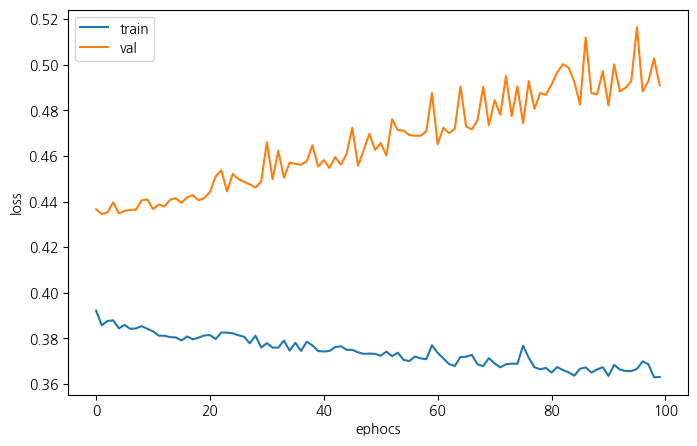

In [43]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=32, validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred)
pred = pred[0].apply(lambda x : 1 if x > 0.5 else 0)
print(classification_report(y_test, pred))

#시각화하기
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('ephocs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# class형으로 만들기 (Model Subclass API)
* class 형태의 모델 정의 방법
* keras의 Model을 상속받아 작성

In [44]:
class Titanic(Model):
    def __init__(self):
        super(Titanic, self).__init__()
        self.dense1 = Dense(128, activation='relu')
        self.dense2 = Dense(64, activation='relu')
        self.dense3 = Dense(32, activation='relu')
        self.dense4 = Dense(16, activation='relu')
        self.classifier = Dense(1, activation='sigmoid')
        
    def call(self, inpruts) :
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        return self.classifier(x)

In [45]:
model = Titanic()
print(model.summary())

Model: "titanic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [48]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=32, validation_data=(mms_X_test, y_test))

pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred)
pred = pred[0].apply(lambda x : 1 if x > 0.5 else 0)
print(classification_report(y_test, pred))

#시각화하기
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('ephocs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

Epoch 1/100


TypeError: Failed to convert elements of (None,) to Tensor. Consider casting elements to a supported type. See https://www.tensorflow.org/api_docs/python/tf/dtypes for supported TF dtypes.

In [ ]:
print(model.summary())